# Week 6 - Day 4: Building and Training a Neural Network with Keras

I continue with the same **Heart Disease Classification** project and the same held-out test split from Day 1.

The goal today is to train the first Keras neural network, read the training history, compare training and validation behavior, then check whether dropout and batch normalization improve the result.

**Task:** binary classification of `HeartDisease` (`0` = no heart disease, `1` = heart disease).

The Day 1 tuned Random Forest remains the classical reference:

- F1 = **0.8846**
- ROC-AUC = **0.9173**
- Accuracy = **0.8696**
- Precision = **0.8679**
- Recall = **0.9020**

I keep the original test set frozen until the final neural-network comparison.

## 1. Imports and project path

The notebook uses TensorFlow/Keras for the network and the same scikit-learn preprocessing approach used on Day 1.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, BatchNormalization, Dropout

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
tf.keras.utils.set_random_seed(RANDOM_STATE)

cwd = Path.cwd().resolve()

data_candidates = [cwd / "heart.csv", cwd / "data" / "heart.csv"]
for root in [cwd, *cwd.parents]:
    data_candidates.append(
        root / "final-project" / "heart-disease-classification" / "data" / "heart.csv"
    )

DATA_PATH = next((path for path in data_candidates if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "heart.csv was not found. Keep the repository structure or place "
        "heart.csv beside this notebook / under a local data directory."
    )

print("TensorFlow:", tf.__version__)
print("Dataset:", DATA_PATH)

TensorFlow: 2.21.0
Dataset: C:\Users\HP\Desktop\BinX-AI-ML-Internship\final-project\heart-disease-classification\data\heart.csv


## 2. Load and clean the project data

I keep the same data-quality rules from Day 1. `RestingBP = 0` and `Cholesterol = 0` are treated as missing values and imputed later from the training data.

In [2]:
df = pd.read_csv(DATA_PATH)

expected_columns = [
    "Age", "Sex", "ChestPainType", "RestingBP", "Cholesterol",
    "FastingBS", "RestingECG", "MaxHR", "ExerciseAngina",
    "Oldpeak", "ST_Slope", "HeartDisease",
]

assert list(df.columns) == expected_columns, "Unexpected dataset schema."

df_clean = df.copy()
df_clean.loc[df_clean["RestingBP"] == 0, "RestingBP"] = np.nan
df_clean.loc[df_clean["Cholesterol"] == 0, "Cholesterol"] = np.nan

print("Shape:", df_clean.shape)
print("Target positive rate:", round(df_clean["HeartDisease"].mean(), 4))

display(df_clean.head())

Shape: (918, 12)
Target positive rate: 0.5534


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


## 3. Keep the Day 1 test split frozen

Day 1 used a stratified 80/20 train/test split with `random_state=42`. I reproduce that exact split first.

The test set is not used to choose the architecture or compare training settings. I take the validation set only from the original training portion.

In [3]:
X = df_clean.drop(columns="HeartDisease")
y = df_clean["HeartDisease"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_full,
)

split_summary = pd.DataFrame(
    {
        "samples": [len(X_train), len(X_val), len(X_test)],
        "positive_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    },
    index=["train", "validation", "test"],
)

display(split_summary.round(4))

,samples,positive_rate
train,587,0.5537
validation,147,0.5510
test,184,0.5543


## 4. Preprocessing

I keep the feature engineering and preprocessing logic consistent with Day 1:

- numeric values are median-imputed and standardized;
- categorical values are most-frequent-imputed and one-hot encoded;
- the same engineered features are added.

The preprocessor is fitted on the **training split only**. Validation and test data are transformed with the fitted preprocessing steps, which avoids leakage.

In [4]:
def add_engineered_features(X_input):
    X_new = X_input.copy()

    expected_max_hr = 220 - X_new["Age"]
    X_new["MaxHRRatio"] = X_new["MaxHR"] / expected_max_hr.replace(0, np.nan)
    X_new["OldpeakPositive"] = (X_new["Oldpeak"] > 0).astype(int)
    X_new["ExerciseOldpeak"] = (
        X_new["Oldpeak"] * (X_new["ExerciseAngina"] == "Y").astype(int)
    )
    X_new["AgeGroup"] = pd.cut(
        X_new["Age"],
        bins=[0, 45, 55, 65, 120],
        labels=["under_45", "45_55", "56_65", "over_65"],
        include_lowest=True,
    ).astype("object")

    return X_new


numeric_features = [
    "Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR",
    "Oldpeak", "MaxHRRatio", "OldpeakPositive", "ExerciseOldpeak",
]

categorical_features = [
    "Sex", "ChestPainType", "RestingECG",
    "ExerciseAngina", "ST_Slope", "AgeGroup",
]

numeric_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    [
        ("num", numeric_preprocessor, numeric_features),
        ("cat", categorical_preprocessor, categorical_features),
    ],
    sparse_threshold=0.0,
)

X_train_features = add_engineered_features(X_train)
X_val_features = add_engineered_features(X_val)
X_test_features = add_engineered_features(X_test)

X_train_nn = preprocessor.fit_transform(X_train_features).astype(np.float32)
X_val_nn = preprocessor.transform(X_val_features).astype(np.float32)
X_test_nn = preprocessor.transform(X_test_features).astype(np.float32)

y_train_nn = y_train.to_numpy(dtype=np.float32)
y_val_nn = y_val.to_numpy(dtype=np.float32)
y_test_nn = y_test.to_numpy(dtype=np.float32)

print("Train shape:", X_train_nn.shape)
print("Validation shape:", X_val_nn.shape)
print("Test shape:", X_test_nn.shape)
print("Input features after preprocessing:", X_train_nn.shape[1])

Train shape: (587, 27)
Validation shape: (147, 27)
Test shape: (184, 27)
Input features after preprocessing: 27


## 5. First Keras model

This is a binary-classification network:

- ReLU is used in the hidden layers;
- the output has one neuron with sigmoid activation;
- binary cross-entropy is the matching loss.

`compile()` only sets the training configuration. The actual training starts in `fit()`.

In [5]:
def build_basic_model(input_dim):
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model


basic_model = build_basic_model(X_train_nn.shape[1])
basic_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train the first model

I use 50 epochs, which is above the Day 4 minimum of 30, and a batch size of 32. Validation data is evaluated after each epoch but does not update the weights.

In [6]:
basic_history = basic_model.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=50,
    batch_size=32,
    verbose=0,
)

basic_history_df = pd.DataFrame(basic_history.history)
basic_history_df.index = np.arange(1, len(basic_history_df) + 1)
basic_history_df.index.name = "epoch"

display(basic_history_df.tail().round(4))

,accuracy,loss,val_accuracy,val_loss
epoch,,,,
46,0.9642,0.1027,0.8435,0.4437
47,0.9659,0.0990,0.8367,0.4477
48,0.9676,0.0954,0.8503,0.4517
49,0.9693,0.0921,0.8435,0.4553
50,0.9710,0.0886,0.8435,0.4613


## 6. Training history

The loss curves are more useful than training accuracy alone. A clear overfitting signal is training loss continuing to fall while validation loss starts rising. If both curves improve together and stay reasonably close, the model is generalizing better.

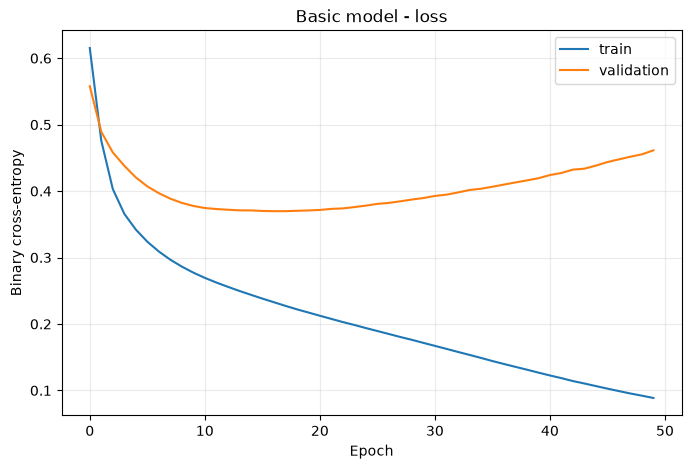

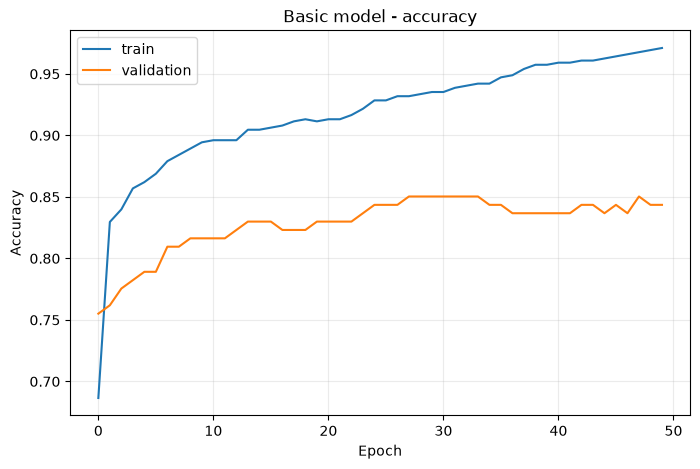

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(basic_history.history["loss"], label="train")
plt.plot(basic_history.history["val_loss"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy")
plt.title("Basic model - loss")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(basic_history.history["accuracy"], label="train")
plt.plot(basic_history.history["val_accuracy"], label="validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Basic model - accuracy")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [8]:
basic_best_epoch = int(np.argmin(basic_history.history["val_loss"])) + 1

basic_training_summary = pd.DataFrame([{
    "best_val_loss_epoch": basic_best_epoch,
    "best_val_loss": np.min(basic_history.history["val_loss"]),
    "best_val_accuracy": np.max(basic_history.history["val_accuracy"]),
    "final_train_loss": basic_history.history["loss"][-1],
    "final_val_loss": basic_history.history["val_loss"][-1],
    "final_train_accuracy": basic_history.history["accuracy"][-1],
    "final_val_accuracy": basic_history.history["val_accuracy"][-1],
}])

display(basic_training_summary.round(4))

,best_val_loss_epoch,best_val_loss,best_val_accuracy,final_train_loss,final_val_loss,final_train_accuracy,final_val_accuracy
0,17,0.3698,0.8503,0.0886,0.4613,0.971,0.8435


### First-run diagnosis

The basic model starts to overfit after the middle of training. Validation loss reaches its minimum at epoch 17 (`0.3698`), then rises to `0.4613` by epoch 50 while training loss keeps falling to `0.0886`. Training accuracy also reaches `0.9710`, while validation accuracy finishes at `0.8435`. The growing train/validation gap shows that continuing to fit the training data is no longer improving generalization.

## 7. Add batch normalization and dropout

For the second run, I keep the main hidden-layer sizes unchanged and add:

- `BatchNormalization()` after the first hidden layer to make the internal activations more stable during training;
- `Dropout(0.3)` to randomly drop 30% of activations during training and reduce reliance on individual paths.

Dropout is active during training and disabled during validation/test evaluation.

In [9]:
def build_regularized_model(input_dim):
    tf.keras.utils.set_random_seed(RANDOM_STATE)

    model = Sequential([
        Input(shape=(input_dim,)),
        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )

    return model


regularized_model = build_regularized_model(X_train_nn.shape[1])
regularized_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 64)                  │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,161 (16.25 KB)

 Trainable params: 4,033 (15.75 KB)

 Non-trainable params: 128 (512.00 B)

In [10]:
regularized_history = regularized_model.fit(
    X_train_nn,
    y_train_nn,
    validation_data=(X_val_nn, y_val_nn),
    epochs=50,
    batch_size=32,
    verbose=0,
)

regularized_history_df = pd.DataFrame(regularized_history.history)
regularized_history_df.index = np.arange(1, len(regularized_history_df) + 1)
regularized_history_df.index.name = "epoch"

display(regularized_history_df.tail().round(4))

,accuracy,loss,val_accuracy,val_loss
epoch,,,,
46,0.9625,0.1106,0.8571,0.4509
47,0.9472,0.1279,0.8503,0.4476
48,0.9540,0.1073,0.8503,0.4461
49,0.9472,0.1224,0.8503,0.4550
50,0.9438,0.1389,0.8435,0.4682


## 8. Compare the two training runs

I compare the two runs using validation results before touching the test set.

The batch-normalized/dropout model reaches a lower best validation loss (`0.3582` vs `0.3698`) and a higher best validation accuracy (`0.8707` vs `0.8503`). It still overfits later in training: its validation loss rises again and finishes at `0.4682`. So the added layers improve the best validation behavior, but they do not remove overfitting by epoch 50.

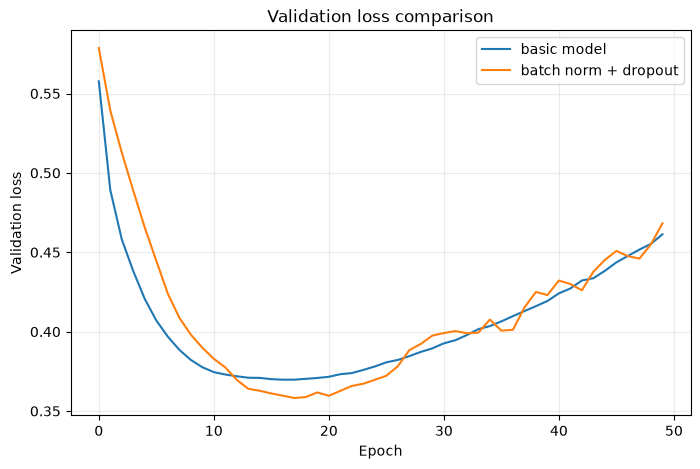

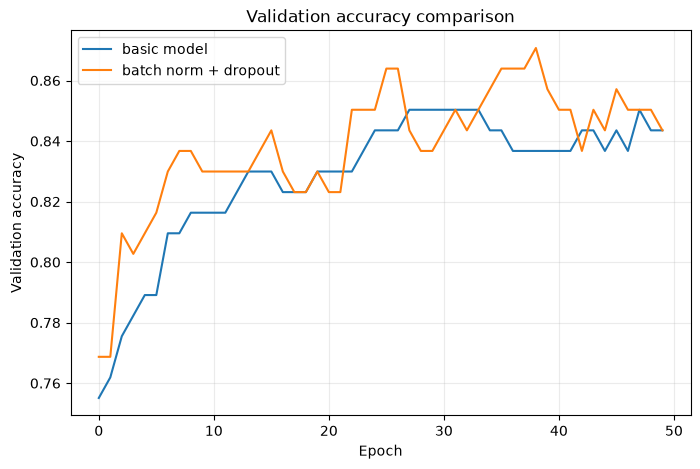

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(basic_history.history["val_loss"], label="basic model")
plt.plot(regularized_history.history["val_loss"], label="batch norm + dropout")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Validation loss comparison")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(basic_history.history["val_accuracy"], label="basic model")
plt.plot(regularized_history.history["val_accuracy"], label="batch norm + dropout")
plt.xlabel("Epoch")
plt.ylabel("Validation accuracy")
plt.title("Validation accuracy comparison")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [12]:
def history_summary(name, history):
    val_loss = np.asarray(history.history["val_loss"])
    val_accuracy = np.asarray(history.history["val_accuracy"])

    return {
        "model": name,
        "best_val_loss": val_loss.min(),
        "best_val_loss_epoch": int(val_loss.argmin()) + 1,
        "best_val_accuracy": val_accuracy.max(),
        "best_val_accuracy_epoch": int(val_accuracy.argmax()) + 1,
        "final_val_loss": val_loss[-1],
        "final_val_accuracy": val_accuracy[-1],
    }


validation_comparison = pd.DataFrame([
    history_summary("Basic neural network", basic_history),
    history_summary("BatchNorm + Dropout", regularized_history),
])

display(validation_comparison.round(4))

,model,best_val_loss,best_val_loss_epoch,best_val_accuracy,best_val_accuracy_epoch,final_val_loss,final_val_accuracy
0,Basic neural network,0.3698,17,0.8503,28,0.4613,0.8435
1,BatchNorm + Dropout,0.3582,18,0.8707,39,0.4682,0.8435


### Model choice

For this Day 4 comparison, I select the configuration with the lower **minimum validation loss**. That is the `BatchNorm + Dropout` model.

I am not using EarlyStopping or ModelCheckpoint yet because those belong to Day 5. Therefore the final `evaluate()` call uses the weights left in the selected model after epoch 50, not the weights from its best validation epoch.

In [13]:
basic_min_val_loss = float(np.min(basic_history.history["val_loss"]))
regularized_min_val_loss = float(np.min(regularized_history.history["val_loss"]))

if regularized_min_val_loss < basic_min_val_loss:
    selected_name = "BatchNorm + Dropout"
    selected_model = regularized_model
else:
    selected_name = "Basic neural network"
    selected_model = basic_model

print("Selected from validation loss:", selected_name)

Selected from validation loss: BatchNorm + Dropout


## 9. Final test evaluation

After choosing the configuration from validation results, I evaluate it once on the frozen Day 1 test set.

Keras `evaluate()` reports the configured loss and accuracy. I also calculate precision, recall, F1, and ROC-AUC so the result is directly comparable with the Day 1 tuned Random Forest.

In [14]:
test_loss, test_accuracy = selected_model.evaluate(
    X_test_nn,
    y_test_nn,
    verbose=0,
)

test_probability = selected_model.predict(X_test_nn, verbose=0).ravel()
test_prediction = (test_probability >= 0.5).astype(int)

nn_metrics = {
    "accuracy": accuracy_score(y_test, test_prediction),
    "precision": precision_score(y_test, test_prediction),
    "recall": recall_score(y_test, test_prediction),
    "f1": f1_score(y_test, test_prediction),
    "roc_auc": roc_auc_score(y_test, test_probability),
}

print("Selected model:", selected_name)
print("Keras test loss:", round(float(test_loss), 4))

display(pd.DataFrame([nn_metrics], index=["Neural Network"]).round(4))

Selected model: BatchNorm + Dropout
Keras test loss: 0.5359


,accuracy,precision,recall,f1,roc_auc
Neural Network,0.8587,0.8585,0.8922,0.875,0.9014


## 10. Compare with the Day 1 baseline

The tuned Random Forest is the fixed classical reference on this exact held-out test set. F1 and ROC-AUC are the main Week 6 comparison metrics.

The neural network reaches **F1 = 0.8750** and **ROC-AUC = 0.9014**. The Day 1 tuned Random Forest remains slightly stronger with **F1 = 0.8846** and **ROC-AUC = 0.9173**.

In [15]:
day1_baseline = {
    "accuracy": 0.8696,
    "precision": 0.8679,
    "recall": 0.9020,
    "f1": 0.8846,
    "roc_auc": 0.9173,
}

comparison = pd.DataFrame(
    [day1_baseline, nn_metrics],
    index=["Day 1 Tuned Random Forest", selected_name],
)

display(comparison.round(4))

f1_delta = nn_metrics["f1"] - day1_baseline["f1"]
auc_delta = nn_metrics["roc_auc"] - day1_baseline["roc_auc"]

print(f"F1 difference vs baseline: {f1_delta:+.4f}")
print(f"ROC-AUC difference vs baseline: {auc_delta:+.4f}")

,accuracy,precision,recall,f1,roc_auc
Day 1 Tuned Random Forest,0.8696,0.8679,0.9020,0.8846,0.9173
BatchNorm + Dropout,0.8587,0.8585,0.8922,0.8750,0.9014


F1 difference vs baseline: -0.0096
ROC-AUC difference vs baseline: -0.0159


## 11. Conclusion

The Day 4 Keras workflow is complete on the same Heart Disease dataset and frozen test split used for the Day 1 baseline.

The basic network shows clear overfitting after its best validation point. Adding batch normalization and dropout improves the best validation loss and validation accuracy, although the second model also begins to overfit later in training.

On the held-out test set, the selected neural network achieves:

- Accuracy = **0.8587**
- Precision = **0.8585**
- Recall = **0.8922**
- F1 = **0.8750**
- ROC-AUC = **0.9014**

Compared with the tuned Random Forest baseline, F1 is lower by `0.0096` and ROC-AUC is lower by `0.0159`. The neural network is competitive, but it does not beat the classical baseline on this dataset. For this tabular problem, the tuned Random Forest remains the stronger model at the end of Day 4.